## Variance experiment collect from the dataset 

## import all the library

In [14]:
import asyncio 
import json 
import random 
from pathlib import Path
from dotenv import load_dotenv 
import sys 
import os 
import httpx
import nest_asyncio
from src.config import Models
from src.Baseline import RandomBaseline
from src.llm_judge import LLMJudge
from src.courtroom_env import CourtroomEnv,RoleAssignment
from data.load_data import TrainingQuery,DataLoader
from src.state_extractor import StateExtractor,QueryState
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path().absolute().parent))
load_dotenv()

nest_asyncio.apply()
ROUTER_KEY = os.getenv('ROUTER_KEY')
OPENROUTER_URL = os.getenv('OPENROUTER_URL')

print('Imports OK')

Imports OK


# verify the api keys


In [3]:
Keys = [ 
    'OP_KEY',"AP_KEY","GP_KEY","GQ_KEY","XP_KEY","HF_TOKEN"
]

for  k in Keys:
    os.getenv(k)
    print(f"Keys are ${k} ")


Keys are $OP_KEY 
Keys are $AP_KEY 
Keys are $GP_KEY 
Keys are $GQ_KEY 
Keys are $XP_KEY 
Keys are $HF_TOKEN 


#  Router setup

In [4]:
async def call_model(model: str, prompt: str, temperature: float = 0.7) -> str:
    
    headers = {
        'Authorization': f'Bearer {ROUTER_KEY}',
        'Content-Type':  'application/json',
        'HTTP-Referer':  'https://github.com/nexomnis',
    }
    payload = {
        'model':       model,
        'messages':    [{'role': 'user', 'content': prompt}],
        'temperature': temperature,
    }

    async with httpx.AsyncClient(timeout=60) as client:
        r = await client.post(OPENROUTER_URL, headers=headers, json=payload)
        r.raise_for_status()
        return r.json()['choices'][0]['message']['content'] or ''



In [5]:

async def call_models_parallel(prompts: dict[str, tuple[str, str]]) -> dict[str, str]:
    """
    Call multiple models in parallel.
    prompts = {role: (model_id, prompt_text)}
    Returns {role: response_text}
    """
    tasks   = {role: call_model(model, prompt) for role, (model, prompt) in prompts.items()}
    results = await asyncio.gather(*tasks.values(), return_exceptions=True)
    return {
        role: (res if not isinstance(res, Exception) else f'[Error: {res}]')
        for role, res in zip(tasks.keys(), results)
    }

print('Helper functions defined')

Helper functions defined


In [6]:
async def verify_models():
    for name in Models:
        try:
            resp = await call_model(name, 'reply with the single word: ok')
            print(f'  ✅   ({name[:3]})')
        except Exception as e:
            print(f'  ❌   ({name[:3]}) → {e}')

await verify_models()

  ✅   (ope)
  ✅   (ant)
  ✅   (goo)
  ✅   (met)
  ✅   (x-a)


In [7]:
N_QUERIES     = 20
N_ASSIGNMENTS = 5

print(f'Queries:      {N_QUERIES}')
print(f'Assignments:  {N_ASSIGNMENTS}')
print(f'Total trials: {N_QUERIES * N_ASSIGNMENTS}')

Queries:      20
Assignments:  5
Total trials: 100


In [8]:
loader  = DataLoader()
queries = loader.load_squad(n=N_QUERIES)   # SQuAD — Parquet native

print(f'\nLoaded {len(queries)} queries')
print('\nSample:')
for q in queries[:3]:
    print(f'  [{q.source}] {q.query[:80]}')

[DataLoader] Loading SQuAD (20 examples)...
[DataLoader] Loaded 20 SQuAD queries

Loaded 20 queries

Sample:
  [squad] To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
  [squad] What is in front of the Notre Dame Main Building?
  [squad] The Basilica of the Sacred heart at Notre Dame is beside to which structure?


In [9]:
env      = CourtroomEnv()
judge    = LLMJudge()
baseline = RandomBaseline()

# Preview one random assignment
sample = baseline.assign()
print('Sample assignment from RandomBaseline:')
print(json.dumps(sample.to_dict(), indent=2))

Sample assignment from RandomBaseline:
{
  "prosecutor": {
    "model": "groq/llama-3.3-70b-versatile",
    "behavior": "Build the strongest argument for the affirmative position"
  },
  "defense": {
    "model": "openai/gpt-4o",
    "behavior": "Challenge the prosecution's claims rigorously"
  },
  "judge_factual": {
    "model": "anthropic/claude-sonnet-4-5",
    "behavior": "Evaluate factual accuracy and evidence grounding"
  },
  "judge_reasoning": {
    "model": "google/gemini-2.5-pro",
    "behavior": "Evaluate logical consistency and reasoning quality"
  },
  "judge_clarity": {
    "model": "x-ai/grok-3",
    "behavior": "Evaluate clarity and communication effectiveness"
  }
}


### DRY RUN: one query, one trial
# Confirms all modules work before running the full experiment


In [10]:

q          = queries[0]
assignment = baseline.assign()

print(f'Query:    {q.query}')
print(f'Evidence: {q.evidence[:200]}...')
print()

result = await env.run(q.query, q.evidence, assignment)
reward = await judge.score(result, q.ground_truth)

print(f'Prosecution:\n{result.prosecution_argument[:300]}')
print(f'\nDefense:\n{result.defense_argument[:300]}')
print(f'\nVerdict: {result.verdict}')
print(f'Reward:  {reward}')

Query:    To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
Evidence: Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper sta...

Prosecution:
In 1858, the Virgin Mary allegedly appeared to Saint Bernadette Soubirous in Lourdes, France. This assertion is supported by the evidence which highlights the historical and religious significance of the Grotto at Lourdes. The evidence describes a Marian place of prayer and reflection that serves as

Defense:
The prosecution's argument relies heavily on religious tradition and architectural symbolism to assert that the Virgin Mary appeared to Saint Bernadette Soubirous in 1858 at Lourdes, France. However, this evidence is circumstantial and lacks direct, verifiable proof of the event. The description of 

Verdict: Confidence: 0.71. Prosecution prevailed on: To whom did the Virgin M

## Full Experiment 

In [11]:

# 20 queries x 5 random assignments
# Expected: 15–30 min

all_results = []

for qi, q in enumerate(queries[:N_QUERIES]):
    print(f'\nQuery {qi+1}/{N_QUERIES}: {q.query[:65]}...')
    rewards = []

    for ai in range(N_ASSIGNMENTS):
        assignment = baseline.assign()
        try:
            result = await env.run(q.query, q.evidence, assignment)
            reward = await judge.score(result, q.ground_truth)
            rewards.append(reward)
            print(f'  [{ai+1}/{N_ASSIGNMENTS}] reward={reward:.3f}')
        except Exception as e:
            print(f'  [{ai+1}/{N_ASSIGNMENTS}] ERROR — {e}')

    if len(rewards) >= 2:
        mean_r = sum(rewards) / len(rewards)
        var_r  = sum((r - mean_r)**2 for r in rewards) / len(rewards)
        std_r  = var_r ** 0.5
        all_results.append({
            'query':   q.query[:80],
            'source':  q.source,
            'rewards': rewards,
            'mean':    round(mean_r, 4),
            'std':     round(std_r,  4),
        })
        print(f'  → mean={mean_r:.3f}  std={std_r:.3f}  range=[{min(rewards):.3f}, {max(rewards):.3f}]')

print('\n✅ Done')


Query 1/20: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes F...
  [1/5] reward=0.400
  [2/5] reward=0.860
  [3/5] reward=0.855
  [4/5] reward=0.800
  [5/5] reward=0.400
  → mean=0.663  std=0.216  range=[0.400, 0.860]

Query 2/20: What is in front of the Notre Dame Main Building?...
  [1/5] reward=0.765
  [2/5] reward=0.850
  [3/5] reward=0.795
  [4/5] reward=0.860
  [5/5] reward=0.765
  → mean=0.807  std=0.041  range=[0.765, 0.860]

Query 3/20: The Basilica of the Sacred heart at Notre Dame is beside to which...
  [1/5] reward=0.830
  [2/5] reward=0.890
  [3/5] reward=0.700
  [4/5] reward=0.620
  [5/5] reward=0.870
  → mean=0.782  std=0.105  range=[0.620, 0.890]

Query 4/20: What is the Grotto at Notre Dame?...
  [1/5] reward=0.800
  [2/5] reward=0.740
  [3/5] reward=0.790
  [4/5] reward=0.765
  [5/5] reward=0.690
  → mean=0.757  std=0.039  range=[0.690, 0.800]

Query 5/20: What sits on top of the Main Building at Notre Dame?...
  [1/5] reward=0.610
  [2/5] reward=0.7

In [12]:
# Cell 8 — Summary statistics
all_stds  = [r['std']  for r in all_results]
all_means = [r['mean'] for r in all_results]

mean_std  = sum(all_stds)  / len(all_stds)
mean_mean = sum(all_means) / len(all_means)
max_std   = max(all_stds)
min_std   = min(all_stds)

print('=' * 50)
print('VARIANCE EXPERIMENT RESULTS')
print('=' * 50)
print(f'Queries evaluated : {len(all_results)}')
print(f'Mean reward       : {mean_mean:.4f}')
print(f'Mean std          : {mean_std:.4f}  ← KEY NUMBER')
print(f'Max std           : {max_std:.4f}')
print(f'Min std           : {min_std:.4f}')
print()
if mean_std > 0.05:
    print('✅ HIGH VARIANCE — DAPO training is JUSTIFIED')
    print('   Role assignment significantly affects quality.')
else:
    print('⚠️  LOW VARIANCE — investigate reward function')
    print('   All assignments performing similarly.')
print('=' * 50)

VARIANCE EXPERIMENT RESULTS
Queries evaluated : 20
Mean reward       : 0.6893
Mean std          : 0.1475  ← KEY NUMBER
Max std           : 0.3271
Min std           : 0.0394

✅ HIGH VARIANCE — DAPO training is JUSTIFIED
   Role assignment significantly affects quality.


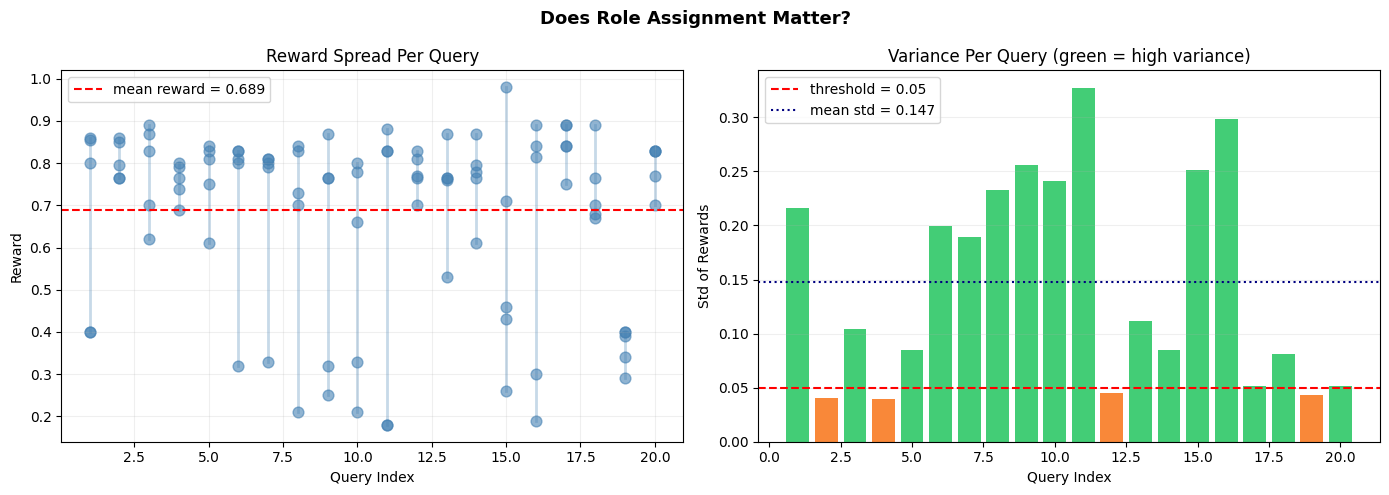

In [16]:
# Cell 9 — Visualize


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: reward spread per query
ax1 = axes[0]
for i, r in enumerate(all_results):
    x = [i + 1] * len(r['rewards'])
    ax1.scatter(x, r['rewards'], alpha=0.6, color='steelblue', s=60)
    ax1.plot([i+1, i+1], [min(r['rewards']), max(r['rewards'])],
             color='steelblue', alpha=0.3, linewidth=2)
ax1.axhline(mean_mean, color='red', linestyle='--', linewidth=1.5,
            label=f'mean reward = {mean_mean:.3f}')
ax1.set_xlabel('Query Index')
ax1.set_ylabel('Reward')
ax1.set_title('Reward Spread Per Query')
ax1.legend()
ax1.grid(True, alpha=0.2)

# Plot 2: std per query
ax2 = axes[1]
colors = ['#22c55e' if s > 0.05 else '#f97316' for s in all_stds]
ax2.bar(range(1, len(all_results)+1), all_stds, color=colors, alpha=0.85)
ax2.axhline(0.05,     color='red',  linestyle='--', linewidth=1.5, label='threshold = 0.05')
ax2.axhline(mean_std, color='navy', linestyle=':',  linewidth=1.5, label=f'mean std = {mean_std:.3f}')
ax2.set_xlabel('Query Index')
ax2.set_ylabel('Std of Rewards')
ax2.set_title('Variance Per Query (green = high variance)')
ax2.legend()
ax2.grid(True, alpha=0.2, axis='y')

plt.suptitle('Does Role Assignment Matter?', fontsize=13, fontweight='bold')
plt.tight_layout()


plt.savefig( 'variance_experiment.png', dpi=150, bbox_inches='tight')
plt.show()
